# Fairness Audit of Income Classification

## Objective

The objective of this notebook is to predict whether an individual's annual
income exceeds $50,000 and audit whether the model behaves differently across
demographic groups.

The notebook investigates:

- whether logistic regression outperforms a majority-class baseline;
- how the probability threshold affects precision, recall and F1-score;
- whether selection rates and error rates differ across sex and race groups;
- whether excluding sensitive attributes is sufficient to prevent disparities;
- which features have the strongest positive and negative model coefficients.

## Machine-learning task

This is a supervised binary-classification problem:

- Class 0: annual income is at most $50,000.
- Class 1: annual income exceeds $50,000.

The sensitive attributes `sex` and `race` are excluded from model training.
They are retained separately for the fairness audit.

Excluding sensitive attributes does not guarantee fairness because other
features may act as proxies or reflect historical social inequalities.

In [ ]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import set_config
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

sns.set_theme(style="whitegrid")

# Just for prevention the Windows/GBK HTML display error that I encountered recently
set_config(display="text")

RANDOM_STATE = 42

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
dataset_path = Path(
    kagglehub.dataset_download(
        "uciml/adult-census-income"
    )
)

csv_files = list(
    dataset_path.rglob("adult.csv")
)

if not csv_files:
    raise FileNotFoundError(
        f"adult.csv was not found inside {dataset_path}"
    )

data_path = csv_files[0]

raw_adult_df = pd.read_csv(data_path)

print(f"Dataset path: {data_path}")
print(f"Dataset shape: {raw_adult_df.shape}")

raw_adult_df.head()

100%|██████████| 450k/450k [00:01<00:00, 448kB/s]

Extracting files...
Dataset path: C:\Users\ADMIN\.cache\kagglehub\datasets\uciml\adult-census-income\versions\3\adult.csv
Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
raw_adult_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
raw_adult_df.describe(
    include="all"
).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,32561.0,NaN,NaN,NaN,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
workclass,32561,9,Private,22696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,32561.0,NaN,NaN,NaN,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education,32561,16,HS-grad,10501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education.num,32561.0,NaN,NaN,NaN,10.080679,2.57272,1.0,9.0,10.0,12.0,16.0
marital.status,32561,7,Married-civ-spouse,14976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,32561,15,Prof-specialty,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,32561,6,Husband,13193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,32561,5,White,27816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,32561,2,Male,21790,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Initial dataset observations

The dataset contains 32,561 observations and 15 original variables. Each row
represents one person recorded in the Adult Census dataset.

Six variables are numerical:

- age;
- census sampling weight;
- numerical education level;
- capital gain;
- capital loss;
- weekly working hours.

The remaining variables describe categorical characteristics such as
workclass, education, marital status, occupation, relationship, race, sex,
native country and income class.

The target contains two classes: `<=50K` and `>50K`. Several categorical
columns use `?` to represent missing information even though the initial
DataFrame summary reports them as non-null strings.

The numerical variables also contain extreme values. Age ranges from 17 to
90, weekly working hours range from 1 to 99, capital gain reaches 99,999 and
capital loss reaches 4,356. The dataset is suitable for binary classification,
but its missing-value symbols, class imbalance and historical demographic
patterns require careful handling.

In [5]:
adult_df = raw_adult_df.copy()

adult_df.columns = (
    adult_df.columns
    .str.strip()
    .str.lower()
    .str.replace(
        r"[^a-z0-9]+",
        "_",
        regex=True
    )
    .str.strip("_")
)

object_columns = adult_df.select_dtypes(
    include="object"
).columns

for column in object_columns:
    adult_df[column] = (
        adult_df[column]
        .astype(str)
        .str.strip()
        .replace(
            {
                "?": np.nan,
                "nan": np.nan
            }
        )
    )

adult_df.columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education_num',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital_gain',
 'capital_loss',
 'hours_per_week',
 'native_country',
 'income']

In [6]:
adult_df["income"] = (
    adult_df["income"]
    .str.replace(
        ".",
        "",
        regex=False
    )
)

print("Income values:")
print(
    adult_df["income"]
    .value_counts(
        dropna=False
    )
)

print("\nMissing values:")
print(
    adult_df
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

Income values:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Missing values:
occupation        1843
workclass         1836
native_country     583
fnlwgt               0
education            0
education_num        0
age                  0
marital_status       0
relationship         0
sex                  0
dtype: int64


In [7]:
adult_df = adult_df.dropna(
    subset=[
        "income",
        "sex",
        "race"
    ]
).copy()

adult_df["target"] = (
    adult_df["income"]
    .eq(">50K")
    .astype(int)
)

print("Cleaned shape:", adult_df.shape)
print(
    "Duplicate rows:",
    adult_df.duplicated().sum()
)

Cleaned shape: (32561, 16)
Duplicate rows: 24


### Data-cleaning findings

After converting question marks to missing values, missing observations were
found in:

- `occupation`: 1,843 missing values;
- `workclass`: 1,836 missing values;
- `native_country`: 583 missing values.

These observations were retained because the preprocessing pipeline later
imputed categorical missing values using the most frequent category.

No observations were missing from the target, sex or race columns, so the
cleaned dataset remained at 32,561 rows. The final DataFrame contained 16
columns after adding the binary target.

The target was encoded as:

- 0 for income at or below $50,000;
- 1 for income above $50,000.

Twenty-four exact duplicate rows were detected and retained. This represents
approximately 0.07% of the dataset, so their effect should be small, although
a future version could test whether removing them changes the results.

In [8]:
target_summary_df = (
    adult_df["target"]
    .value_counts()
    .sort_index()
    .rename_axis("target")
    .reset_index(name="observations")
)

target_summary_df["percentage"] = (
    target_summary_df["observations"]
    / len(adult_df)
    * 100
)

target_summary_df

,target,observations,percentage
0,0,24720,75.919044
1,1,7841,24.080956


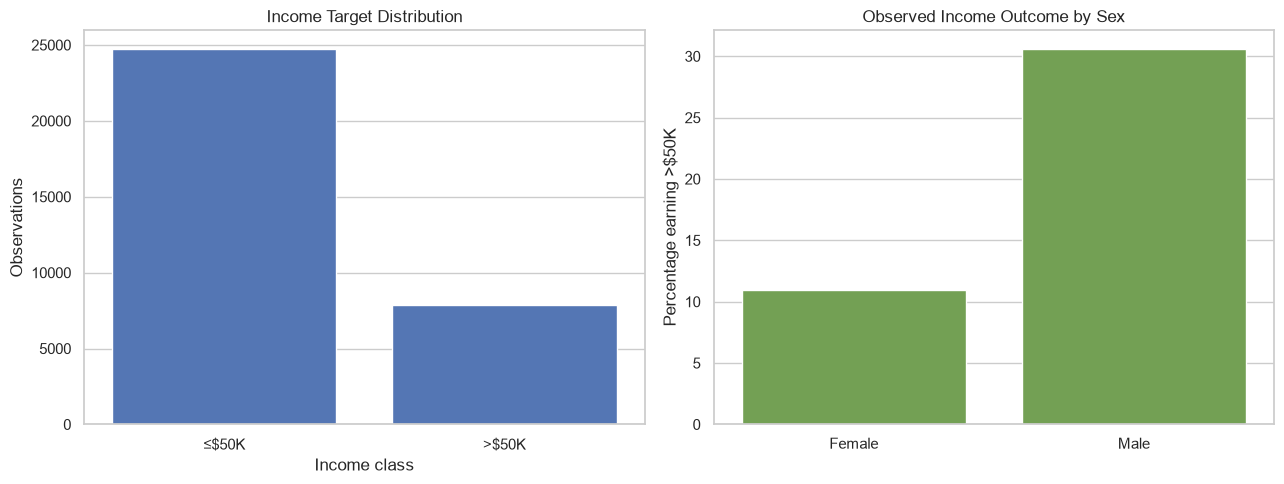

In [9]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

sns.countplot(
    data=adult_df,
    x="target",
    color="#4472C4",
    ax=axes[0]
)

axes[0].set_title("Income Target Distribution")
axes[0].set_xlabel("Income class")
axes[0].set_ylabel("Observations")
axes[0].set_xticks(
    [0, 1],
    ["≤$50K", ">$50K"]
)

income_by_sex_df = (
    adult_df
    .groupby(
        "sex",
        observed=True
    )["target"]
    .mean()
    .mul(100)
    .reset_index(
        name="above_50k_percentage"
    )
)

sns.barplot(
    data=income_by_sex_df,
    x="sex",
    y="above_50k_percentage",
    color="#70AD47",
    ax=axes[1]
)

axes[1].set_title(
    "Observed Income Outcome by Sex"
)
axes[1].set_xlabel("")
axes[1].set_ylabel(
    "Percentage earning >$50K"
)

plt.tight_layout()
plt.show()

In [10]:
income_by_race_df = (
    adult_df
    .groupby(
        "race",
        observed=True
    )
    .agg(
        observations=(
            "target",
            "size"
        ),
        above_50k_rate=(
            "target",
            "mean"
        )
    )
    .sort_values(
        "observations",
        ascending=False
    )
    .reset_index()
)

income_by_race_df[
    "above_50k_rate"
] *= 100

income_by_race_df

,race,observations,above_50k_rate
0,White,27816,25.585994
1,Black,3124,12.387964
2,Asian-Pac-Islander,1039,26.564004
3,Amer-Indian-Eskimo,311,11.575563
4,Other,271,9.225092


### Target and demographic observations

The target was imbalanced:

- Income at or below $50K: 24,720 observations, or 75.92%;
- Income above $50K: 7,841 observations, or 24.08%.

Therefore, a classifier predicting the majority class for every observation
could achieve approximately 76% accuracy while detecting none of the
higher-income observations.

The observed positive-income rate also differed considerably across sex
groups. Approximately 10.9% of female observations earned more than $50K,
compared with approximately 30.6% of male observations.

Observed rates by race were:

| Race | Observations | Income above $50K |
|---|---:|---:|
| White | 27,816 | 25.59% |
| Black | 3,124 | 12.39% |
| Asian-Pac-Islander | 1,039 | 26.56% |
| Amer-Indian-Eskimo | 311 | 11.58% |
| Other | 271 | 9.23% |

The race groups were highly imbalanced. Results for the smaller groups should
be treated cautiously because a small number of predictions can produce
large changes in their measured rates.

These differences describe the historical dataset and do not show that the
machine-learning model caused them.

In [11]:
excluded_model_columns = [
    "income",
    "target",
    "sex",
    "race",
    "fnlwgt",
    "education"
]

X = adult_df.drop(
    columns=excluded_model_columns
)

y = adult_df["target"]

audit_attributes_df = adult_df[
    [
        "sex",
        "race"
    ]
].copy()

print("Model features:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Model features:
['age', 'workclass', 'education_num', 'marital_status', 'occupation', 'relationship', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country']

Feature shape: (32561, 10)
Target shape: (32561,)


In [12]:
(
    X_development,
    X_test,
    y_development,
    y_test,
    audit_development,
    audit_test
) = train_test_split(
    X,
    y,
    audit_attributes_df,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

(
    X_train,
    X_validation,
    y_train,
    y_validation,
    audit_train,
    audit_validation
) = train_test_split(
    X_development,
    y_development,
    audit_development,
    test_size=0.25,
    stratify=y_development,
    random_state=RANDOM_STATE
)

print(f"Training observations:   {len(X_train):,}")
print(f"Validation observations: {len(X_validation):,}")
print(f"Test observations:       {len(X_test):,}")

print("\nTarget rates:")
print(
    pd.Series(
        {
            "training": y_train.mean(),
            "validation": y_validation.mean(),
            "test": y_test.mean()
        }
    )
)

Training observations:   19,536
Validation observations: 6,512
Test observations:       6,513

Target rates:
training      0.240837
validation    0.240786
test          0.240749
dtype: float64


### Data-splitting 

The dataset was divided into:

- Training set: 19,536 observations;
- Validation set: 6,512 observations;
- Test set: 6,513 observations.

Stratification preserved the positive-class rate across all subsets:

- Training: 24.08%;
- Validation: 24.08%;
- Test: 24.07%.

The training set was used to fit preprocessing and logistic regression. The
validation set was used to select the probability threshold. The test set was
reserved for the final performance and fairness evaluation.

Keeping the test set separate prevents threshold selection from being
influenced by the data used for final reporting.

In [13]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Categorical features:
['workclass', 'marital_status', 'occupation', 'relationship', 'native_country']


In [14]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=10,
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [15]:
baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor)
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                solver="liblinear",
                random_state=RANDOM_STATE
            )
        )
    ]
)


In [16]:
baseline_pipeline.fit(
    X_train,
    y_train
)

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Models trained successfully.")

Models trained successfully.


In [17]:
def calculate_classification_metrics(
    model_name,
    y_true,
    predictions,
    probabilities
):
    return {
        "model": model_name,
        "accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            probabilities
        )
    }

In [18]:
baseline_predictions = (
    baseline_pipeline
    .predict(X_test)
)

baseline_probabilities = (
    baseline_pipeline
    .predict_proba(X_test)[:, 1]
)

default_test_probabilities = (
    logistic_pipeline
    .predict_proba(X_test)[:, 1]
)

default_test_predictions = (
    default_test_probabilities
    >= 0.50
).astype(int)

model_evaluation_df = pd.DataFrame(
    [
        calculate_classification_metrics(
            "Majority baseline",
            y_test,
            baseline_predictions,
            baseline_probabilities
        ),
        calculate_classification_metrics(
            "Logistic regression",
            y_test,
            default_test_predictions,
            default_test_probabilities
        )
    ]
)

model_evaluation_df

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Majority baseline,0.759251,0.500000,0.000000,0.000000,0.000000,0.500000
1,Logistic regression,0.854906,0.773136,0.738332,0.615434,0.671304,0.899392


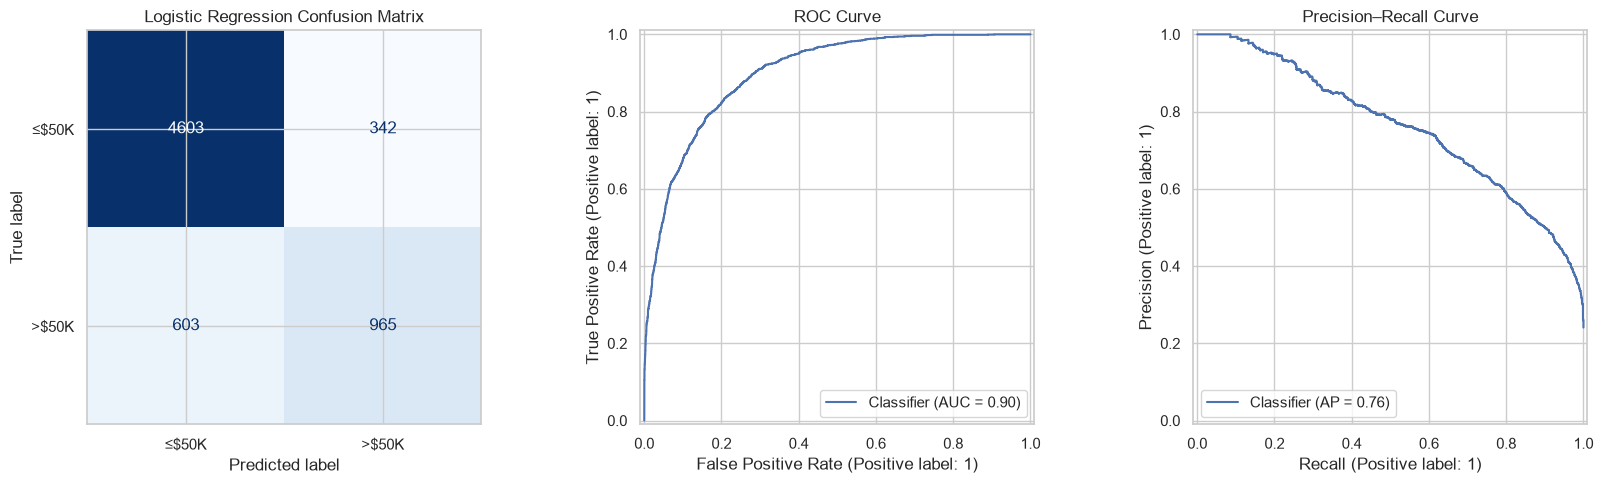

In [19]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    default_test_predictions,
    display_labels=[
        "≤$50K",
        ">$50K"
    ],
    cmap="Blues",
    ax=axes[0],
    colorbar=False
)

axes[0].set_title(
    "Logistic Regression Confusion Matrix"
)

RocCurveDisplay.from_predictions(
    y_test,
    default_test_probabilities,
    ax=axes[1]
)

axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_test,
    default_test_probabilities,
    ax=axes[2]
)

axes[2].set_title(
    "Precision–Recall Curve"
)

plt.tight_layout()
plt.show()

### Initial model-performance findings

| Model | Accuracy | Balanced accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Majority baseline | 75.93% | 50.00% | 0.00% | 0.00% | 0.000 | 0.500 |
| Logistic regression | 85.49% | 77.31% | 73.83% | 61.54% | 0.671 | 0.899 |

The majority baseline predicted the lower-income class for every observation.
Although it achieved 75.93% accuracy, it had zero precision, recall and
F1-score for the higher-income class. Its balanced accuracy of 50% and
ROC-AUC of 0.5 confirm that it provided no useful class discrimination.

At the default 0.50 threshold, logistic regression produced:

- True negatives: 4,603;
- False positives: 342;
- False negatives: 603;
- True positives: 965.

The model correctly identified approximately 61.5% of the higher-income
observations, and 73.8% of its positive predictions were correct. Its
ROC-AUC of 0.899 shows strong probability ranking even though the fixed
threshold missed a substantial number of positive cases.

This demonstrates why accuracy alone is insufficient. The baseline obtained
high accuracy from class imbalance while failing completely on the minority
class.

## Fairness metrics

This notebook uses several group-level measurements:

- **Actual positive rate:** proportion that truly earns more than $50K.
- **Selection rate:** proportion predicted to earn more than $50K.
- **True-positive rate:** proportion of actual positive cases correctly found.
- **False-positive rate:** proportion of actual negative cases incorrectly
  predicted as positive.
- **Precision:** proportion of positive predictions that are correct.

The following gap measures compare the highest and lowest group values:

- **Demographic-parity gap:** difference in selection rates.
- **Equal-opportunity gap:** difference in true-positive rates.
- **False-positive-rate gap:** difference in false-positive rates.
- **Equalized-odds gap:** the larger of the TPR and FPR gaps.

A smaller gap indicates more similar measured behaviour across groups, but no
single metric provides a complete definition of fairness.

In [20]:
def safe_divide(
    numerator,
    denominator
):
    if denominator == 0:
        return np.nan

    return numerator / denominator


def calculate_group_metrics(
    y_true,
    predictions,
    groups,
    group_name
):
    evaluation_df = pd.DataFrame(
        {
            "y_true": np.asarray(y_true),
            "prediction":
                np.asarray(predictions),
            group_name:
                np.asarray(groups)
        }
    )

    rows = []

    for group_value, group_df in (
        evaluation_df.groupby(
            group_name,
            observed=True
        )
    ):
        tn, fp, fn, tp = confusion_matrix(
            group_df["y_true"],
            group_df["prediction"],
            labels=[0, 1]
        ).ravel()

        rows.append(
            {
                group_name: group_value,
                "observations": len(group_df),
                "actual_positive_rate":
                    group_df["y_true"].mean(),
                "selection_rate":
                    group_df["prediction"].mean(),
                "true_positive_rate":
                    safe_divide(
                        tp,
                        tp + fn
                    ),
                "false_positive_rate":
                    safe_divide(
                        fp,
                        fp + tn
                    ),
                "precision":
                    safe_divide(
                        tp,
                        tp + fp
                    ),
                "accuracy":
                    (
                        group_df["y_true"]
                        == group_df["prediction"]
                    ).mean()
            }
        )

    return pd.DataFrame(rows)


def calculate_fairness_gaps(
    group_metrics_df
):
    selection_rates = (
        group_metrics_df[
            "selection_rate"
        ].dropna()
    )

    tpr_values = (
        group_metrics_df[
            "true_positive_rate"
        ].dropna()
    )

    fpr_values = (
        group_metrics_df[
            "false_positive_rate"
        ].dropna()
    )

    selection_rate_gap = (
        selection_rates.max()
        - selection_rates.min()
    )

    selection_rate_ratio = safe_divide(
        selection_rates.min(),
        selection_rates.max()
    )

    tpr_gap = (
        tpr_values.max()
        - tpr_values.min()
    )

    fpr_gap = (
        fpr_values.max()
        - fpr_values.min()
    )

    return {
        "selection_rate_gap":
            selection_rate_gap,
        "selection_rate_ratio":
            selection_rate_ratio,
        "true_positive_rate_gap":
            tpr_gap,
        "false_positive_rate_gap":
            fpr_gap,
        "equalized_odds_gap":
            max(
                tpr_gap,
                fpr_gap
            )
    }

In [21]:
validation_probabilities = (
    logistic_pipeline
    .predict_proba(
        X_validation
    )[:, 1]
)

threshold_rows = []

for threshold in np.arange(
    0.20,
    0.81,
    0.05
):
    validation_predictions = (
        validation_probabilities
        >= threshold
    ).astype(int)

    sex_metrics = calculate_group_metrics(
        y_validation,
        validation_predictions,
        audit_validation["sex"],
        "sex"
    )

    sex_gaps = calculate_fairness_gaps(
        sex_metrics
    )

    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision_score(
                y_validation,
                validation_predictions,
                zero_division=0
            ),
            "recall": recall_score(
                y_validation,
                validation_predictions,
                zero_division=0
            ),
            "f1": f1_score(
                y_validation,
                validation_predictions,
                zero_division=0
            ),
            "predicted_positive_rate":
                validation_predictions.mean(),
            "sex_selection_rate_gap":
                sex_gaps[
                    "selection_rate_gap"
                ],
            "sex_tpr_gap":
                sex_gaps[
                    "true_positive_rate_gap"
                ]
        }
    )

threshold_analysis_df = pd.DataFrame(
    threshold_rows
)

threshold_analysis_df

,threshold,precision,recall,f1,predicted_positive_rate,sex_selection_rate_gap,sex_tpr_gap
0,0.20,0.535156,0.873724,0.663760,0.393120,0.326713,0.120705
1,0.25,0.570864,0.829719,0.676371,0.349969,0.298540,0.118784
2,0.30,0.604938,0.781250,0.681881,0.310964,0.259164,0.101631
3,0.35,0.639444,0.734056,0.683492,0.276413,0.230600,0.090968
4,0.40,0.660736,0.686862,0.673546,0.250307,0.212541,0.100257
5,0.45,0.690574,0.644770,0.666887,0.224816,0.189836,0.085624
6,0.50,0.710366,0.594388,0.647222,0.201474,0.169639,0.081183
7,0.55,0.733047,0.544643,0.624954,0.178900,0.151979,0.057541
8,0.60,0.759682,0.487883,0.594175,0.154638,0.129714,0.040604
9,0.65,0.795612,0.439413,0.566146,0.132985,0.113427,0.053380


In [22]:
best_threshold = float(
    threshold_analysis_df.loc[
        threshold_analysis_df[
            "f1"
        ].idxmax(),
        "threshold"
    ]
)

print(
    "Validation-selected threshold:",
    f"{best_threshold:.2f}"
)

Validation-selected threshold: 0.35


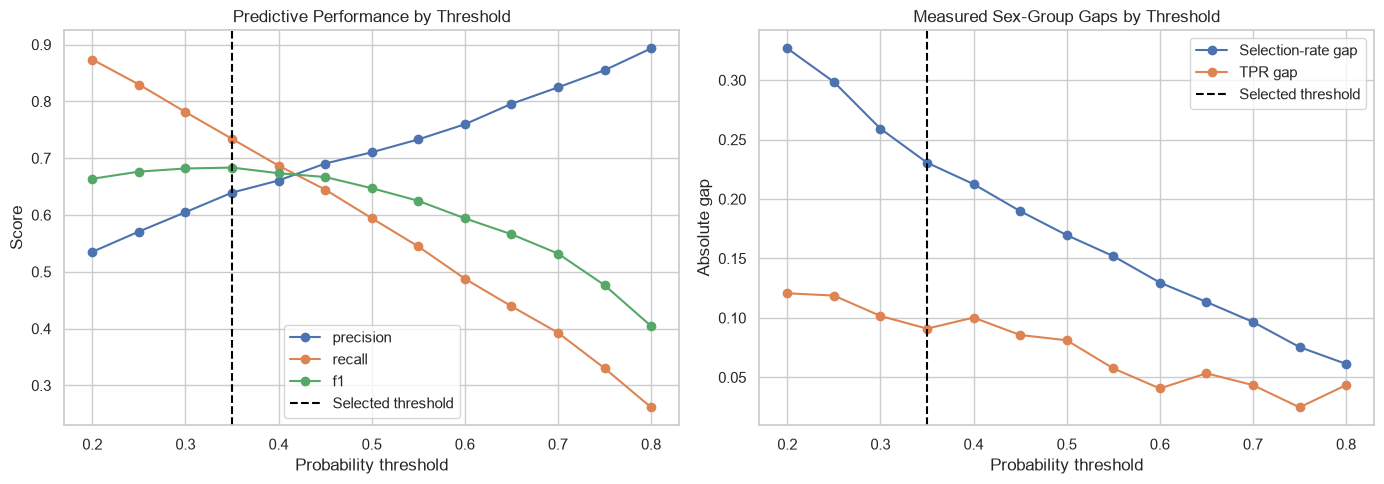

In [23]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

for metric in [
    "precision",
    "recall",
    "f1"
]:
    axes[0].plot(
        threshold_analysis_df[
            "threshold"
        ],
        threshold_analysis_df[metric],
        marker="o",
        label=metric
    )

axes[0].axvline(
    best_threshold,
    linestyle="--",
    color="black",
    label="Selected threshold"
)

axes[0].set_title(
    "Predictive Performance by Threshold"
)
axes[0].set_xlabel("Probability threshold")
axes[0].set_ylabel("Score")
axes[0].legend()

axes[1].plot(
    threshold_analysis_df[
        "threshold"
    ],
    threshold_analysis_df[
        "sex_selection_rate_gap"
    ],
    marker="o",
    label="Selection-rate gap"
)

axes[1].plot(
    threshold_analysis_df[
        "threshold"
    ],
    threshold_analysis_df[
        "sex_tpr_gap"
    ],
    marker="o",
    label="TPR gap"
)

axes[1].axvline(
    best_threshold,
    linestyle="--",
    color="black",
    label="Selected threshold"
)

axes[1].set_title(
    "Measured Sex-Group Gaps by Threshold"
)
axes[1].set_xlabel("Probability threshold")
axes[1].set_ylabel("Absolute gap")
axes[1].legend()

plt.tight_layout()
plt.show()

### Threshold-analysis findings

The validation set selected a probability threshold of 0.35 because it
produced the highest validation F1-score of 0.683.

At this threshold, validation performance was:

- Precision: 63.94%;
- Recall: 73.41%;
- F1-score: 0.683;
- Predicted-positive rate: 27.64%.

As the threshold increased, precision improved while recall declined. For
example, precision increased from 53.52% at a threshold of 0.20 to 89.32% at
0.80, while recall declined from 87.37% to 26.15%.

Lower thresholds classified more observations as positive. This improved
recall but also generally increased the measured sex-group selection-rate
gap. At the selected threshold of 0.35, the validation selection-rate gap was
23.06 percentage points and the TPR gap was 9.10 points. At 0.50, these gaps
were smaller at 16.96 and 8.12 points respectively.

The threshold was selected only by validation F1-score, not by a fairness
constraint. Its predictive benefit therefore did not guarantee smaller
demographic-group gaps.

In [24]:
selected_test_predictions = (
    default_test_probabilities
    >= best_threshold
).astype(int)

threshold_test_comparison_df = pd.DataFrame(
    [
        calculate_classification_metrics(
            "Default threshold 0.50",
            y_test,
            default_test_predictions,
            default_test_probabilities
        ),
        calculate_classification_metrics(
            f"Selected threshold {best_threshold:.2f}",
            y_test,
            selected_test_predictions,
            default_test_probabilities
        )
    ]
)

threshold_test_comparison_df

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Default threshold 0.50,0.854906,0.773136,0.738332,0.615434,0.671304,0.899392
1,Selected threshold 0.35,0.836020,0.800768,0.639043,0.732781,0.682709,0.899392


### Final threshold-performance 

| Threshold | Accuracy | Balanced accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Default 0.50 | 85.49% | 77.31% | 73.83% | 61.54% | 0.671 | 0.899 |
| Selected 0.35 | 83.60% | 80.08% | 63.90% | 73.28% | 0.683 | 0.899 |

Reducing the threshold from 0.50 to 0.35 increased recall by 11.74 percentage
points and improved F1-score from 0.671 to 0.683. Balanced accuracy also
increased from 77.31% to 80.08%.

The selected threshold changed the confusion-matrix outcomes approximately
as follows:

- True positives increased from 965 to 1,149;
- False negatives decreased from 603 to 419;
- False positives increased from 342 to 649;
- True negatives decreased from 4,603 to 4,296.

The model therefore detected 184 additional higher-income observations but
also created 307 additional false-positive predictions. Overall accuracy and
precision declined because of this trade-off.

ROC-AUC remained 0.899 because changing the threshold does not change the
ordering of predicted probabilities.

In [25]:
sex_metrics_df = calculate_group_metrics(
    y_test,
    selected_test_predictions,
    audit_test["sex"],
    "sex"
)

sex_metrics_df

,sex,observations,actual_positive_rate,selection_rate,true_positive_rate,false_positive_rate,precision,accuracy
0,Female,2153,0.110543,0.119833,0.684874,0.049608,0.631783,0.921040
1,Male,4360,0.305046,0.353211,0.741353,0.182838,0.640260,0.794037


In [26]:
sex_fairness_gaps_df = pd.DataFrame(
    [
        calculate_fairness_gaps(
            sex_metrics_df
        )
    ]
)

sex_fairness_gaps_df

,selection_rate_gap,selection_rate_ratio,true_positive_rate_gap,false_positive_rate_gap,equalized_odds_gap
0,0.233378,0.339267,0.056479,0.13323,0.13323


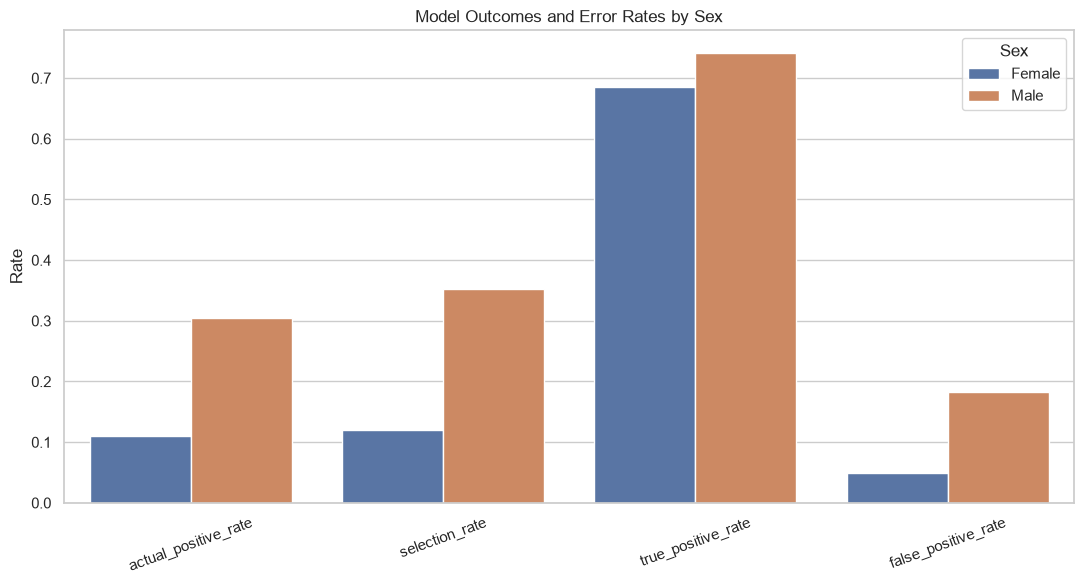

In [27]:
sex_plot_df = sex_metrics_df.melt(
    id_vars=[
        "sex",
        "observations"
    ],
    value_vars=[
        "actual_positive_rate",
        "selection_rate",
        "true_positive_rate",
        "false_positive_rate"
    ],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=sex_plot_df,
    x="metric",
    y="value",
    hue="sex"
)

plt.title(
    "Model Outcomes and Error Rates by Sex"
)
plt.xlabel("")
plt.ylabel("Rate")
plt.xticks(rotation=20)
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

### Sex-group fairness findings

| Metric | Female | Male |
|---|---:|---:|
| Test observations | 2,153 | 4,360 |
| Actual positive rate | 11.05% | 30.50% |
| Selection rate | 11.98% | 35.32% |
| True-positive rate | 68.49% | 74.14% |
| False-positive rate | 4.96% | 18.28% |
| Precision | 63.18% | 64.03% |
| Accuracy | 92.10% | 79.40% |

Male observations were approximately 23.34 percentage points more likely to
receive a positive prediction. The female-to-male selection-rate ratio was
0.339, meaning the female selection rate was approximately 33.9% of the male
rate.

The equal-opportunity or TPR gap was smaller at 5.65 percentage points. The
model correctly identified 74.14% of male positive cases and 68.49% of female
positive cases.

The false-positive-rate gap was larger at 13.32 percentage points. Male
negative cases were considerably more likely to be incorrectly classified as
positive. Because this was the largest error-rate difference, the measured
equalized-odds gap was also 13.32 percentage points.

Precision was similar across the two groups, but accuracy was higher for
female observations. This was partly influenced by their much lower positive
class prevalence.

The differences show measurable group disparities, but they do not establish
their cause or prove discrimination. They may reflect class prevalence,
historical relationships in the data, proxy variables and model error.

In [28]:
race_metrics_df = calculate_group_metrics(
    y_test,
    selected_test_predictions,
    audit_test["race"],
    "race"
).sort_values(
    "observations",
    ascending=False
)

race_metrics_df

,race,observations,actual_positive_rate,selection_rate,true_positive_rate,false_positive_rate,precision,accuracy
4,White,5627,0.255020,0.289675,0.735889,0.136927,0.647853,0.830638
2,Black,579,0.127807,0.160622,0.702703,0.081188,0.559140,0.891192
1,Asian-Pac-Islander,196,0.260204,0.280612,0.666667,0.144828,0.618182,0.806122
0,Amer-Indian-Eskimo,67,0.104478,0.223881,0.857143,0.150000,0.400000,0.850746
3,Other,44,0.022727,0.113636,1.000000,0.093023,0.200000,0.909091


In [29]:
race_fairness_gaps_df = pd.DataFrame(
    [
        calculate_fairness_gaps(
            race_metrics_df
        )
    ]
)

race_fairness_gaps_df

,selection_rate_gap,selection_rate_ratio,true_positive_rate_gap,false_positive_rate_gap,equalized_odds_gap
0,0.176038,0.392289,0.333333,0.068812,0.333333


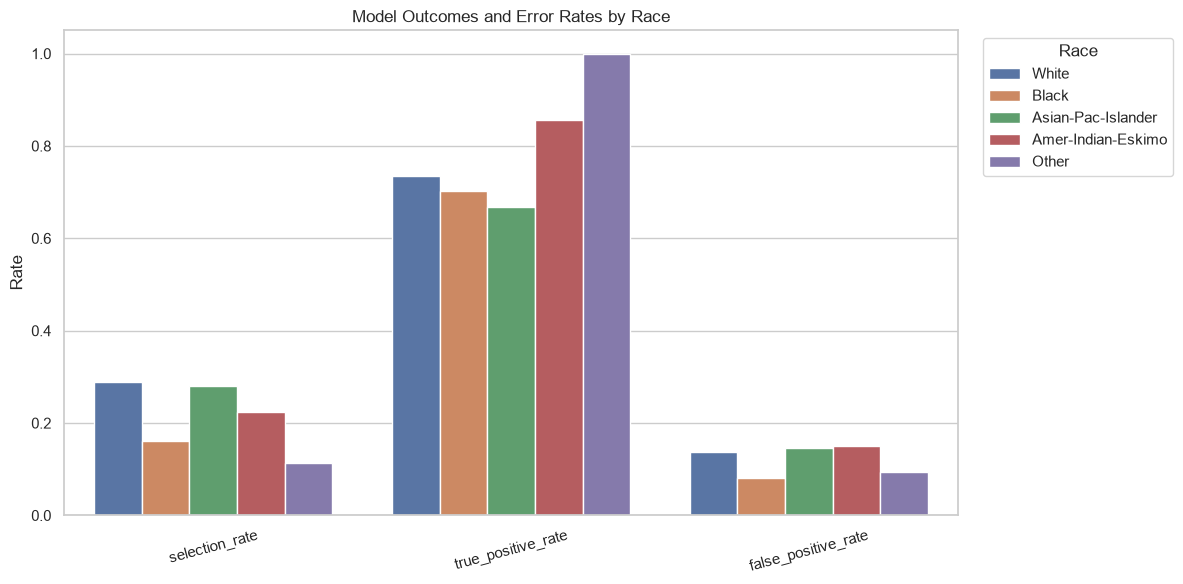

In [30]:
race_plot_df = race_metrics_df.melt(
    id_vars=[
        "race",
        "observations"
    ],
    value_vars=[
        "selection_rate",
        "true_positive_rate",
        "false_positive_rate"
    ],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=race_plot_df,
    x="metric",
    y="value",
    hue="race"
)

plt.title(
    "Model Outcomes and Error Rates by Race"
)
plt.xlabel("")
plt.ylabel("Rate")
plt.xticks(rotation=15)
plt.legend(
    title="Race",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

### Race-group fairness findings

| Race | Test observations | Selection rate | TPR | FPR | Precision |
|---|---:|---:|---:|---:|---:|
| White | 5,627 | 28.97% | 73.59% | 13.69% | 64.79% |
| Black | 579 | 16.06% | 70.27% | 8.12% | 55.91% |
| Asian-Pac-Islander | 196 | 28.06% | 66.67% | 14.48% | 61.82% |
| Amer-Indian-Eskimo | 67 | 22.39% | 85.71% | 15.00% | 40.00% |
| Other | 44 | 11.36% | 100.00% | 9.30% | 20.00% |

The selection-rate gap between the highest and lowest groups was 17.60
percentage points. The minimum-to-maximum selection-rate ratio was 0.392.

The measured TPR gap was 33.33 percentage points, while the FPR gap was 6.88
points. The equalized-odds gap was therefore 33.33 points.

However, the apparently perfect 100% TPR for the `Other` group was based on
only one actual positive observation. Similarly, the Amer-Indian-Eskimo
group contained only seven positive cases. Their TPR estimates are therefore
highly unstable.

The larger groups provided more reliable estimates. Their TPRs were 73.59%
for White observations, 70.27% for Black observations and 66.67% for
Asian-Pac-Islander observations.

The results provide evidence of measured differences, but the largest race
gaps are strongly influenced by very small subgroup samples. Confidence
intervals or repeated resampling would be required for a more reliable
comparison.

In [31]:
fairness_threshold_rows = []

for threshold_name, predictions in [
    (
        "Default 0.50",
        default_test_predictions
    ),
    (
        f"Selected {best_threshold:.2f}",
        selected_test_predictions
    )
]:
    sex_table = calculate_group_metrics(
        y_test,
        predictions,
        audit_test["sex"],
        "sex"
    )

    race_table = calculate_group_metrics(
        y_test,
        predictions,
        audit_test["race"],
        "race"
    )

    sex_gaps = calculate_fairness_gaps(
        sex_table
    )

    race_gaps = calculate_fairness_gaps(
        race_table
    )

    fairness_threshold_rows.append(
        {
            "threshold": threshold_name,
            "sex_selection_rate_gap":
                sex_gaps[
                    "selection_rate_gap"
                ],
            "sex_tpr_gap":
                sex_gaps[
                    "true_positive_rate_gap"
                ],
            "race_selection_rate_gap":
                race_gaps[
                    "selection_rate_gap"
                ],
            "race_tpr_gap":
                race_gaps[
                    "true_positive_rate_gap"
                ]
        }
    )

fairness_threshold_comparison_df = (
    pd.DataFrame(
        fairness_threshold_rows
    )
)

fairness_threshold_comparison_df

,threshold,sex_selection_rate_gap,sex_tpr_gap,race_selection_rate_gap,race_tpr_gap
0,Default 0.50,0.171413,0.046926,0.114034,0.470588
1,Selected 0.35,0.233378,0.056479,0.176038,0.333333


### Threshold and fairness comparison

| Metric | Default 0.50 | Selected 0.35 |
|---|---:|---:|
| Sex selection-rate gap | 17.14% | 23.34% |
| Sex TPR gap | 4.69% | 5.65% |
| Race selection-rate gap | 11.40% | 17.60% |
| Race TPR gap | 47.06% | 33.33% |

Selecting the 0.35 threshold improved overall recall, balanced accuracy and
F1-score, but it increased both the sex and race selection-rate gaps.

The sex TPR gap also increased slightly from 4.69 to 5.65 percentage points.
In contrast, the measured race TPR gap declined from 47.06 to 33.33 points,
although this comparison was unstable because some race groups contained
very few positive observations.

The selected threshold therefore improved one fairness measurement while
worsening several others. Better predictive performance did not
automatically produce better fairness outcomes.

A single global threshold generally cannot equalise selection rates, TPRs,
FPRs and predictive performance simultaneously. Choosing an appropriate
fairness objective would require information about the model's real decision
context and the relative consequences of different errors.

In [32]:
fitted_preprocessor = (
    logistic_pipeline
    .named_steps["preprocessor"]
)

fitted_classifier = (
    logistic_pipeline
    .named_steps["classifier"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

coefficient_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient":
            fitted_classifier.coef_[0]
    }
)

top_positive_coefficients_df = (
    coefficient_df
    .nlargest(
        10,
        "coefficient"
    )
)

top_negative_coefficients_df = (
    coefficient_df
    .nsmallest(
        10,
        "coefficient"
    )
)

pd.concat(
    [
        top_positive_coefficients_df,
        top_negative_coefficients_df
    ],
    ignore_index=True
)

,feature,coefficient
0,numeric__capital_gain,2.382438
1,categorical__native_country_Cambodia,1.355375
2,categorical__marital_status_Married-civ-spouse,1.202811
3,categorical__native_country_Italy,0.904099
4,categorical__occupation_Exec-managerial,0.837217
5,numeric__education_num,0.768465
6,categorical__marital_status_Married-AF-spouse,0.665465
7,categorical__relationship_Wife,0.656381
8,categorical__occupation_Tech-support,0.653449
9,categorical__native_country_Germany,0.603710


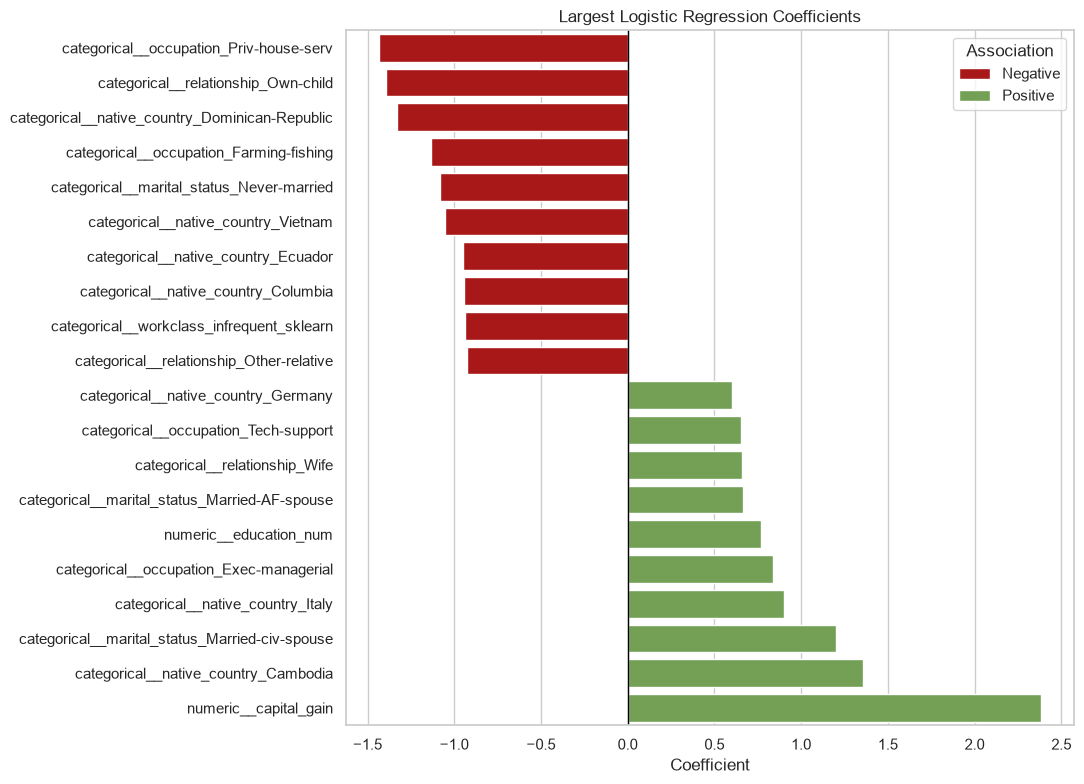

In [33]:
coefficient_plot_df = pd.concat(
    [
        top_negative_coefficients_df,
        top_positive_coefficients_df
    ]
).sort_values(
    "coefficient"
)

coefficient_plot_df[
    "direction"
] = np.where(
    coefficient_plot_df[
        "coefficient"
    ] >= 0,
    "Positive",
    "Negative"
)

plt.figure(figsize=(11, 8))

sns.barplot(
    data=coefficient_plot_df,
    x="coefficient",
    y="feature",
    hue="direction",
    palette={
        "Positive": "#70AD47",
        "Negative": "#C00000"
    },
    dodge=False
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Largest Logistic Regression Coefficients"
)
plt.xlabel("Coefficient")
plt.ylabel("")
plt.legend(title="Association")
plt.tight_layout()
plt.show()

### Model-coefficient 

The largest positive coefficient was standardised `capital_gain` at 2.382,
making it the model's strongest positive predictor. Other notable positive
coefficients included:

- Cambodia native-country category: 1.355;
- married-civilian-spouse marital status: 1.203;
- Italy native-country category: 0.904;
- executive-managerial occupation: 0.837;
- education level: 0.768;
- technical-support occupation: 0.653.

The strongest negative coefficients included:

- private-house-service occupation: -1.432;
- own-child relationship: -1.391;
- Dominican Republic native-country category: -1.328;
- farming-fishing occupation: -1.132;
- never-married status: -1.082;
- Vietnam native-country category: -1.055.

The coefficients show that capital gains, education, occupation, marital
status and relationship information strongly influenced predictions.

Some country coefficients may be unstable because they are based on
relatively small groups. They should not be interpreted as reliable general
claims about people from those countries.

Although sex and race were excluded, variables such as marital status,
relationship, occupation and working hours may be correlated with them.
These variables can therefore preserve demographic disparities through
proxy relationships.

Numerical variables were standardised, so their coefficients represent a
one-standard-deviation change. The one-hot encoder retained all category
columns rather than selecting one omitted reference category. Because the
model used regularisation, individual categorical coefficients should be
interpreted as model associations under this coding scheme, not as simple
causal comparisons with one reference group.